### University of Virginia
### DS 5110: Big Data Systems
### K-Means Cluster Analysis of Fidelity Fund Returns 
### Last updated: March 11, 2023

## Instructions

In this assignment, you will conduct a k-means cluster analysis on a set of Fidelity mutual funds.  
This helps to group similar funds based on their performance (as opposed to their description, which is typical).  
The outline below will walk you through the required steps.  

This assignment is worth a total of **10 POINTS.**

## Data Details 

The file *fido_returns_funds_on_rows.csv* is the processed data for k-means. Additional details about this file: 
- Each row represents a mutual fund  
- Each column represents a trading day (these are used as features)  
- Each value represents the daily percentage change in price between the current trading day and previous trading day

### Load Modules and Read Data into Spark DataFrame

In [2]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

data = spark.read.csv('fido_returns_funds_on_rows.csv', header=True, inferSchema=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/09 20:24:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/09 20:24:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
                                                                                

**(VALUE: 2 POINTS) Assemble the Features into a column. 
Show the first five rows of data ONLY for the features column.
(this should make things easier to read)**

In [31]:
assembler = VectorAssembler(inputCols=data.columns, outputCol="features")
assembled = assembler.transform(data)
assembled.select('features').show(5)

+--------------------+
|            features|
+--------------------+
|[0.0,0.0,-0.01040...|
|[0.0,0.0,-0.01051...|
|[0.0,0.0,-0.01076...|
|[0.0,8.26105E-4,-...|
|[0.0,8.2815740000...|
+--------------------+
only showing top 5 rows


**(VALUE: 1 POINT) Set up the k-means model and train the model**  
Use parameters: 
- 3 clusters
- maximum of 10 iterations 
- seed=314

In [32]:
kmeans = KMeans().setK(3).setSeed(314).setMaxIter(10)
km_model = kmeans.fit(assembled)

26/07/09 20:38:14 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/09 20:38:21 WARN DAGScheduler: Broadcasting large task binary with size 1018.9 KiB
                                                                                

**(VALUE: 2 POINTS) Compute and Print the Silhouette Score**  

In [37]:
preds = km_model.transform(assembled)

evaluator = ClusteringEvaluator()
sil_score = evaluator.evaluate(preds)
print(f'The silhouette score is {round(sil_score, 5)}') 

[Stage 60:>                                                         (0 + 1) / 1]

The silhouette score is 0.49487


**(VALUE: 2 POINTS) Define a function `kmeans_range()` that does the following:**
- takes an integer representing the lower bound for k
- takes an integer representing the upper bound for k
- take a Spark DataFrame containing training data
- fit K-means with k ranging from lower bound to upper bound, inclusive  
- the other parameters should be the same as earlier 
- for each k, compute the silhouette score
- return a pandas dataframe with columns containing k, silhouette score (each row holds the score for given k)

In [77]:
import pandas as pd

def kmeans_range(lower, upper, data):
    '''
    lower: lower bound for k, inclusive
    upper: upper bound for k, inclusive
    data: training data, without a column 'features'
    '''
    evaluator = ClusteringEvaluator()
    assembler = VectorAssembler(inputCols=data.columns, outputCol='features')
    assembled_data = assembler.transform(data) 
    results = []
    for k in range(lower, upper+1):
        km = KMeans().setK(k).setSeed(314).setMaxIter(10)
        m = km.fit(assembled_data)
        p = m.transform(assembled_data)
        ss = evaluator.evaluate(p)
        results.append({"k": k, "sil_score": ss})
    return(pd.DataFrame(results))

**(VALUE: 1 POINT) Call `kmeans_range` to compute K-means with clusters ranging from 2 to 10 inclusive, printing the resulting dataframe.**

In [84]:
res = kmeans_range(2, 10, data)
print(res)

26/07/09 21:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1005.3 KiB
26/07/09 21:58:07 WARN DAGScheduler: Broadcasting large task binary with size 1018.9 KiB
26/07/09 21:58:13 WARN DAGScheduler: Broadcasting large task binary with size 1032.4 KiB
26/07/09 21:58:19 WARN DAGScheduler: Broadcasting large task binary with size 1045.9 KiB
26/07/09 21:58:24 WARN DAGScheduler: Broadcasting large task binary with size 1059.5 KiB
26/07/09 21:58:30 WARN DAGScheduler: Broadcasting large task binary with size 1073.0 KiB
26/07/09 21:58:36 WARN DAGScheduler: Broadcasting large task binary with size 1086.5 KiB
26/07/09 21:58:41 WARN DAGScheduler: Broadcasting large task binary with size 1100.1 KiB
26/07/09 21:58:47 WARN DAGScheduler: Broadcasting large task binary with size 1113.6 KiB


    k  sil_score
0   2   0.602396
1   3   0.494875
2   4   0.500796
3   5   0.459426
4   6   0.419757
5   7   0.462851
6   8   0.304614
7   9   0.371187
8  10   0.403217


**(VALUE: 1 POINT) Produce a plot with cluster numbers k on the x-axis, sihouette scores on the y-axis**

Text(0.5, 1.0, 'KMeans Clustering with Varied Cluster Count\non Fidelity Mutual Funds')

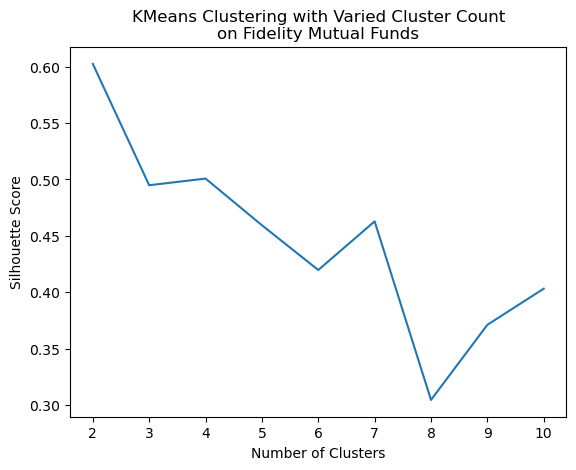

In [83]:
import matplotlib.pyplot as plt

plt.plot(res['k'], res['sil_score'])
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('KMeans Clustering with Varied Cluster Count\non Fidelity Mutual Funds')

**(VALUE: 1 POINT) Based on how the silhouette score is calculated, what is its time complexity? (e.g., O(log n))**  
You can find the definition of the silhouette score in the lecture notes, for example. 

Walking through, step by step:

*1) For each observation (point), compute A and B with these definitions:* **n**

   *A : The mean distance of each point to its neighbors within its cluster (called the *mean intra-cluster distance*).* **(n-k), aka n (because worst-case scenario nearly all other points are in the same cluster )**
 
   *B : the mean distance of each point to its next-closest cluster (called the *mean nearest-cluster distance*). The `min()` function in the illustration above determines the mean distance of the nearest cluster.* **(n-1), aka n (could have all other points in the OTHER cluster)**

   *For well-assigned points, quantity *A* should be much smaller than quantity *B**

*2) Compute for each point *i* the quantity:*  $ s(i) = (B - A) / max(A, B)$ **n**

*3) The mean is then computed over all s(i) to arrive at the silhoutte score.* **n**

**FINAL**: O($n*(n+n)+2n$) = O($2n^2+2n$) = O($n^2$)